## Pydantic with gemini

In [1]:
from dotenv import load_dotenv
import os
from google import genai

load_dotenv()

client = genai.Client(api_key = os.getenv("GEMINI_API_KEY"))
response = client.models.generate_content(model = "gemini-2.5-flash", contents = "tell me a joke")
print(response.text)


Why don't scientists trust atoms?

Because they make up everything!


In [2]:
response = client.models.generate_content(
    model="gemini-2.5-flash", contents="""
    You are a helpful assistant. I need you to create a JSON object representing a library. 
    The library's name should be 'Coolu Libraru' and have the fields name and books that contains a list of book. 
    Each book should have a 'title', 'author', and 'year' field. Make sure the output is a single, valid JSON object. Give me 10 books. 
    Remove ```json and `` """,
)

response.text

'{\n  "name": "Coolu Libraru",\n  "books": [\n    {\n      "title": "The Grand Illusion",\n      "author": "Elara Vance",\n      "year": 2018\n    },\n    {\n      "title": "Whispers of the Forgotten",\n      "author": "Kaelen Thorne",\n      "year": 2005\n    },\n    {\n      "title": "Chronicles of the Stardust",\n      "author": "Seraphina Moon",\n      "year": 2022\n    },\n    {\n      "title": "The Silent City",\n      "author": "Marius Blackwood",\n      "year": 1999\n    },\n    {\n      "title": "Echoes in the Deep",\n      "author": "Lyra Sterling",\n      "year": 2011\n    },\n    {\n      "title": "The Alchemist\'s Secret",\n      "author": "Arthur Finch",\n      "year": 1987\n    },\n    {\n      "title": "Gardens of Tomorrow",\n      "author": "Willow Green",\n      "year": 2020\n    },\n    {\n      "title": "Beneath the Crimson Sky",\n      "author": "Rowan Ashworth",\n      "year": 2015\n    },\n    {\n      "title": "The Clockwork Heart",\n      "author": "Genevieve D

In [3]:
print(response.text)

{
  "name": "Coolu Libraru",
  "books": [
    {
      "title": "The Grand Illusion",
      "author": "Elara Vance",
      "year": 2018
    },
    {
      "title": "Whispers of the Forgotten",
      "author": "Kaelen Thorne",
      "year": 2005
    },
    {
      "title": "Chronicles of the Stardust",
      "author": "Seraphina Moon",
      "year": 2022
    },
    {
      "title": "The Silent City",
      "author": "Marius Blackwood",
      "year": 1999
    },
    {
      "title": "Echoes in the Deep",
      "author": "Lyra Sterling",
      "year": 2011
    },
    {
      "title": "The Alchemist's Secret",
      "author": "Arthur Finch",
      "year": 1987
    },
    {
      "title": "Gardens of Tomorrow",
      "author": "Willow Green",
      "year": 2020
    },
    {
      "title": "Beneath the Crimson Sky",
      "author": "Rowan Ashworth",
      "year": 2015
    },
    {
      "title": "The Clockwork Heart",
      "author": "Genevieve Dubois",
      "year": 2008
    },
    {
      "

## Pydantic to validate the simulated data

In [4]:
from pydantic import BaseModel, Field
from datetime import datetime

class Book(BaseModel):
    title: str
    author: str
    year: int = Field(gt = 1000, lt = datetime.now().year)

class Library(BaseModel):
    name: str
    books: list[Book]


library = Library.model_validate_json(response.text)
library


Library(name='Coolu Libraru', books=[Book(title='The Grand Illusion', author='Elara Vance', year=2018), Book(title='Whispers of the Forgotten', author='Kaelen Thorne', year=2005), Book(title='Chronicles of the Stardust', author='Seraphina Moon', year=2022), Book(title='The Silent City', author='Marius Blackwood', year=1999), Book(title='Echoes in the Deep', author='Lyra Sterling', year=2011), Book(title="The Alchemist's Secret", author='Arthur Finch', year=1987), Book(title='Gardens of Tomorrow', author='Willow Green', year=2020), Book(title='Beneath the Crimson Sky', author='Rowan Ashworth', year=2015), Book(title='The Clockwork Heart', author='Genevieve Dubois', year=2008), Book(title='Path of the Wanderer', author='Caleb Stone', year=1993)])

In [5]:
library.name

'Coolu Libraru'

In [6]:
library.books

[Book(title='The Grand Illusion', author='Elara Vance', year=2018),
 Book(title='Whispers of the Forgotten', author='Kaelen Thorne', year=2005),
 Book(title='Chronicles of the Stardust', author='Seraphina Moon', year=2022),
 Book(title='The Silent City', author='Marius Blackwood', year=1999),
 Book(title='Echoes in the Deep', author='Lyra Sterling', year=2011),
 Book(title="The Alchemist's Secret", author='Arthur Finch', year=1987),
 Book(title='Gardens of Tomorrow', author='Willow Green', year=2020),
 Book(title='Beneath the Crimson Sky', author='Rowan Ashworth', year=2015),
 Book(title='The Clockwork Heart', author='Genevieve Dubois', year=2008),
 Book(title='Path of the Wanderer', author='Caleb Stone', year=1993)]

In [7]:
library.books[1]

Book(title='Whispers of the Forgotten', author='Kaelen Thorne', year=2005)

In [8]:
library.books[1].title, library.books[1].year

('Whispers of the Forgotten', 2005)

In [9]:
titles = [book.title for book in library.books]

titles

['The Grand Illusion',
 'Whispers of the Forgotten',
 'Chronicles of the Stardust',
 'The Silent City',
 'Echoes in the Deep',
 "The Alchemist's Secret",
 'Gardens of Tomorrow',
 'Beneath the Crimson Sky',
 'The Clockwork Heart',
 'Path of the Wanderer']

In [10]:
newer_books = [(book.title, book.year) for book in library.books if book.year > 1970]
newer_books

[('The Grand Illusion', 2018),
 ('Whispers of the Forgotten', 2005),
 ('Chronicles of the Stardust', 2022),
 ('The Silent City', 1999),
 ('Echoes in the Deep', 2011),
 ("The Alchemist's Secret", 1987),
 ('Gardens of Tomorrow', 2020),
 ('Beneath the Crimson Sky', 2015),
 ('The Clockwork Heart', 2008),
 ('Path of the Wanderer', 1993)]

In [11]:
library.model_dump()

{'name': 'Coolu Libraru',
 'books': [{'title': 'The Grand Illusion',
   'author': 'Elara Vance',
   'year': 2018},
  {'title': 'Whispers of the Forgotten',
   'author': 'Kaelen Thorne',
   'year': 2005},
  {'title': 'Chronicles of the Stardust',
   'author': 'Seraphina Moon',
   'year': 2022},
  {'title': 'The Silent City', 'author': 'Marius Blackwood', 'year': 1999},
  {'title': 'Echoes in the Deep', 'author': 'Lyra Sterling', 'year': 2011},
  {'title': "The Alchemist's Secret", 'author': 'Arthur Finch', 'year': 1987},
  {'title': 'Gardens of Tomorrow', 'author': 'Willow Green', 'year': 2020},
  {'title': 'Beneath the Crimson Sky',
   'author': 'Rowan Ashworth',
   'year': 2015},
  {'title': 'The Clockwork Heart', 'author': 'Genevieve Dubois', 'year': 2008},
  {'title': 'Path of the Wanderer', 'author': 'Caleb Stone', 'year': 1993}]}

In [12]:
library.model_dump_json(indent=4)

'{\n    "name": "Coolu Libraru",\n    "books": [\n        {\n            "title": "The Grand Illusion",\n            "author": "Elara Vance",\n            "year": 2018\n        },\n        {\n            "title": "Whispers of the Forgotten",\n            "author": "Kaelen Thorne",\n            "year": 2005\n        },\n        {\n            "title": "Chronicles of the Stardust",\n            "author": "Seraphina Moon",\n            "year": 2022\n        },\n        {\n            "title": "The Silent City",\n            "author": "Marius Blackwood",\n            "year": 1999\n        },\n        {\n            "title": "Echoes in the Deep",\n            "author": "Lyra Sterling",\n            "year": 2011\n        },\n        {\n            "title": "The Alchemist\'s Secret",\n            "author": "Arthur Finch",\n            "year": 1987\n        },\n        {\n            "title": "Gardens of Tomorrow",\n            "author": "Willow Green",\n            "year": 2020\n        },\n 

In [13]:
with open("library.json", "w") as json_file:
    json_file.write(library.model_dump_json(indent=4))

create pandas dataframe

In [14]:
import pandas as pd

titles = [book.title for book in library.books]
years = [book.year for book in library.books]
authors = [book.author for book in library.books]

df = pd.DataFrame({"title": titles, "year": years, "author": authors})

,title,year,author
0,The Grand Illusion,2018,Elara Vance
1,Whispers of the Forgotten,2005,Kaelen Thorne
2,Chronicles of the Stardust,2022,Seraphina Moon
3,The Silent City,1999,Marius Blackwood
4,Echoes in the Deep,2011,Lyra Sterling
5,The Alchemist's Secret,1987,Arthur Finch
6,Gardens of Tomorrow,2020,Willow Green
7,Beneath the Crimson Sky,2015,Rowan Ashworth
8,The Clockwork Heart,2008,Genevieve Dubois
9,Path of the Wanderer,1993,Caleb Stone


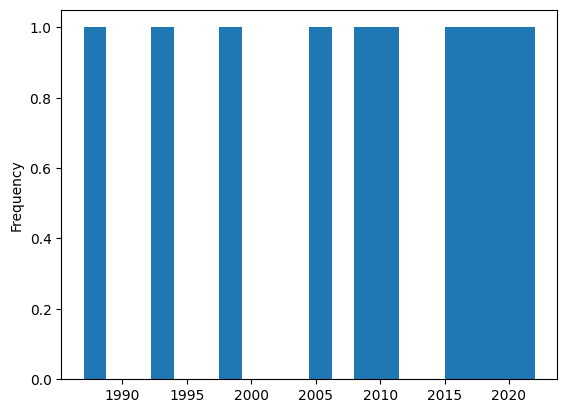

In [15]:
df["year"].plot(kind = "hist", bins =20)
df